<a href="https://colab.research.google.com/github/pelinumur-maker/dsa210-project-cranberry/blob/main/dsa_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Null Hypothesis: The playcount per listener ratio is the same for artists who use AI and artists that dont use AI.

Alternative Hypothesis: Artists that use AI have lower playcount per listener ratio.

In [1]:
!pip install matplotlib==3.10.6 \
numpy==2.3.3\
pandas==2.3.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 18.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sourc



---



In [77]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path().resolve()
ENRICHED_PATH = DATA_DIR / "deezer_lastfm_enriched10.csv"

if not ENRICHED_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at {ENRICHED_PATH}")

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.2f}".format



---



In [47]:
preview_lines = []
with ENRICHED_PATH.open() as f:
    for line in f:
        preview_lines.append(line.strip())
        if len(preview_lines) == 6:
            break

for line in preview_lines:
    print(line)


artist_id,artist_name,artist_nb_albums,artist_fans_deezer,album_id,album_title,album_url,release_date,nb_tracks,genre,deezer_fans,ai_flagged,ai_flag_text,scrape_error,search_query,lastfm_artist_found,lastfm_artist_name,artist_playcount,artist_listeners,artist_url,album_playcount,album_match_type,album_match_score
57547,Roy Eldridge,210,4043,583576392,"All That Jazz, Vol. 42: Roy Eldridge ""New York - Paris!"" (Remastered 2015)",https://www.deezer.com/en/album/583576392,2015-09-04,24,Caz,4,False,,,jazz 2025,True,Roy Eldridge,406109,71192,https://www.last.fm/music/Roy+Eldridge,11614,exact,100
179227037,Inframundo Beats,24,0,344517947,Free Instrumental de Dancehall - Sabores (Uso Libre) Pista Reggaeton Romantico Dancehall 2022,https://www.deezer.com/en/album/344517947,2022-08-05,1,"Reggae, Dancehall/Ragga",5,False,,,reggaeton 2025,True,Inframundo Beats,2,1,https://www.last.fm/music/Inframundo+Beats,0,exact,100
366448032,The Introverted Marketer 2025,14,0,890626942,Neo Soul Instrumentals (



---



In [48]:
mydata = pd.read_csv(ENRICHED_PATH)
mydata.head()
mydata.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1585 entries, 0 to 1584
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   artist_id            1585 non-null   int64  
 1   artist_name          1585 non-null   object 
 2   artist_nb_albums     1585 non-null   int64  
 3   artist_fans_deezer   1585 non-null   int64  
 4   album_id             1585 non-null   int64  
 5   album_title          1585 non-null   object 
 6   album_url            1585 non-null   object 
 7   release_date         1585 non-null   object 
 8   nb_tracks            1585 non-null   int64  
 9   genre                1385 non-null   object 
 10  deezer_fans          1585 non-null   int64  
 11  ai_flagged           1585 non-null   bool   
 12  ai_flag_text         263 non-null    object 
 13  scrape_error         3 non-null      object 
 14  search_query         1585 non-null   object 
 15  lastfm_artist_found  1585 non-null   b



---



In [49]:
columns_of_interest = ["artist_name", "artist_fans_deezer", "lastfm_artist_name", "artist_listeners", "artist_playcount"]
summary = mydata[columns_of_interest].describe(include="all")
summary

,artist_name,artist_fans_deezer,lastfm_artist_name,artist_listeners,artist_playcount
count,1585,1585.00,1439,1439.00,1439.00
unique,1583,NaN,1437,NaN,NaN
top,Çeşitli Sanatçılar,NaN,Çeşitli Sanatçılar,NaN,NaN
freq,2,NaN,2,NaN,NaN
mean,NaN,52022.36,NaN,93505.68,4168375.08
std,NaN,525828.43,NaN,452132.24,36371844.21
min,NaN,0.00,NaN,1.00,1.00
25%,NaN,1.00,NaN,22.50,101.50
50%,NaN,29.00,NaN,574.00,3611.00
75%,NaN,616.00,NaN,11947.50,125878.00




---



In [50]:
top_ai_artists = (
    mydata
    .query("ai_flagged == True and lastfm_artist_found == True")
    .sort_values(by="artist_listeners", ascending=False)
    .loc[:, ["artist_name", "album_title", "artist_fans_deezer", "artist_listeners", "artist_playcount"]]
    .head(5)
)
top_ai_artists

,artist_name,album_title,artist_fans_deezer,artist_listeners,artist_playcount
45,Mikel,"Techno Trance 2025, VOL. 1",2,180732.00,9395594.00
1318,Makoto,japanese Rock (Remastered 2025),2,123362.00,1684143.00
1435,Ray,Dance Pop 2025,2363,120591.00,3180771.00
988,Lily,uk drill type beat (2024),1007,81875.00,807485.00
1266,Nox,Vibe Tonight (Afrobeats Chill Mix 2025 | 20 Sm...,126,77093.00,766672.00




---



In [51]:
top_non_ai_artists = (
    mydata
    .query("ai_flagged == False and lastfm_artist_found == True")
    .sort_values(by="artist_listeners", ascending=False)
    .loc[:, ["artist_name", "album_title", "artist_fans_deezer", "artist_listeners", "artist_playcount"]]
    .head(5)
)
top_non_ai_artists

,artist_name,album_title,artist_fans_deezer,artist_listeners,artist_playcount
592,Linkin Park,From Zero (Deluxe Edition),12088681,6964963.00,751412244.00
626,Pink Floyd,The Dark Side Of The Moon (50th Anniversary) [...,6754275,5578757.00,613083693.00
1394,Metallica,Blackened 2020,8070065,5205644.00,538161744.00
687,U2,Days Of Ash EP,7265794,5056063.00,231494933.00
392,Pixies,"Live from Red Rocks Amphitheatre, Denver, CO. ...",1088898,4297455.00,217053327.00




---



In [65]:
ai_artist_avg_listeners= mydata.groupby("ai_flagged")["artist_listeners"].mean()
ai_artist_avg_listeners

,artist_listeners
ai_flagged,
False,107507.80
True,4179.39




---



In [78]:
listeners_summary_by_ai = mydata.groupby("ai_flagged")["artist_listeners"].agg(["mean", "median", "count"])
listeners_summary_by_ai

,mean,median,count
ai_flagged,,,
False,107507.80,1151.50,1244
True,4179.39,11.00,195




---



In [54]:
playcount_summary_by_ai = mydata.groupby("ai_flagged")["artist_playcount"].agg(["mean", "median", "count"])
playcount_summary_by_ai

,mean,median,count
ai_flagged,,,
False,4807482.86,7206.00,1244
True,91195.19,46.00,195


   

---








In [67]:
"""calculated the plays-per-listener ratio and added it as a new column to my dataset"""
mydata_with_ratio = mydata.assign(playcount_to_listener_ratio = mydata["artist_playcount"] / mydata["artist_listeners"])







---









In [68]:
ratio_summary_by_ai = mydata_with_ratio.groupby("ai_flagged")["playcount_to_listener_ratio"].agg(["mean", "median", "count"])
ratio_summary_by_ai

,mean,median,count
ai_flagged,,,
False,13.46,6.33,1244
True,8.11,3.08,195




---



In [57]:
mydata_with_ratio_for_albums = mydata.assign(
    album_playcount_to_listener_ratio = mydata["album_playcount"] / mydata["artist_listeners"]
)

album_ratio_summary_by_ai = mydata_with_ratio_for_albums.groupby("ai_flagged")["album_playcount_to_listener_ratio"].agg(["mean", "median", "count"])
album_ratio_summary_by_ai

,mean,median,count
ai_flagged,,,
False,2.77,0.06,1244
True,4.11,0.00,195


--------------------------------------------------------------------


# Plots


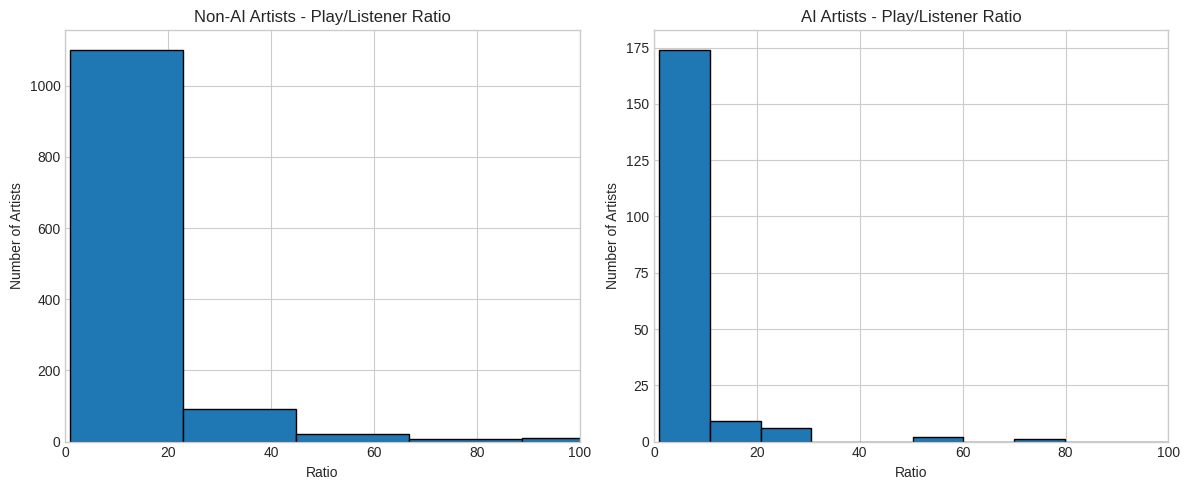

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2,figsize=(12,5))

for ax,flag,label in zip(axes, [False, True], ["Non-AI", "AI"]):
    subset = mydata_with_ratio[mydata_with_ratio["ai_flagged"]==flag]["playcount_to_listener_ratio"].dropna()
    ax.hist(subset, bins=30, edgecolor = 'black')
    ax.set_title(f"{label} Artists - Play/Listener Ratio")
    ax.set_xlabel("Ratio")
   # ax.set_xscale("log")
    ax.set_ylabel("Number of Artists")
    ax.set_xlim(0, 100)


plt.tight_layout()
plt.show()


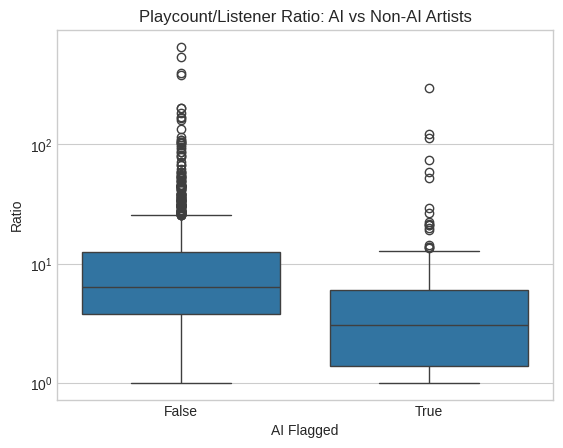

In [70]:
"""Boxplot"""

sns.boxplot(data = mydata_with_ratio, x="ai_flagged", y= "playcount_to_listener_ratio")
plt.title("Playcount/Listener Ratio: AI vs Non-AI Artists")
plt.xlabel("AI Flagged")
plt.ylabel("Ratio")
plt.yscale("log")

plt.show()

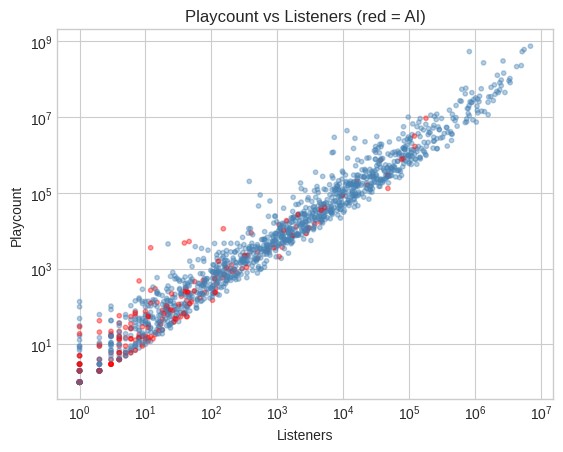

In [60]:
"""Scatter Plot"""

colors = mydata_with_ratio["ai_flagged"].map({True: "red", False: "steelblue"})
plt.scatter(mydata_with_ratio["artist_listeners"], mydata_with_ratio["artist_playcount"], c=colors, alpha=0.4, s=10)
plt.xlabel("Listeners")
plt.ylabel("Playcount")
plt.title("Playcount vs Listeners (red = AI)")
plt.xscale("log")
plt.yscale("log")
plt.show()


# ML Methods

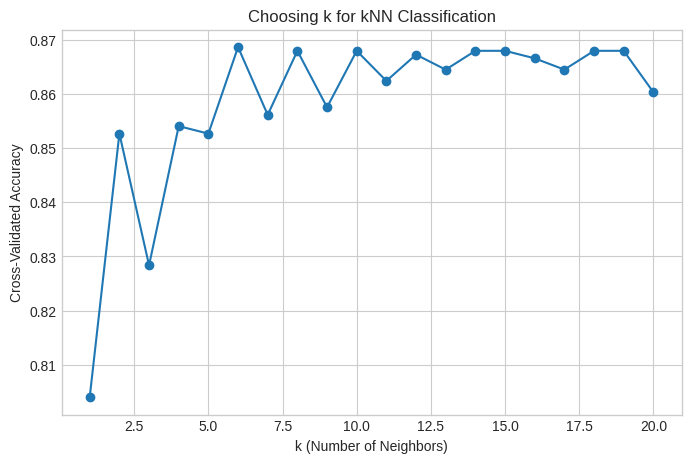

Best k: 6
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.50      0.11      0.18        37

    accuracy                           0.87       288
   macro avg       0.69      0.55      0.55       288
weighted avg       0.83      0.87      0.83       288



In [61]:
"""KNN"""


# Used the code from week 9 recitation

from sklearn.datasets import make_regression, make_classification
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report



features = ["artist_listeners", "artist_playcount", "artist_fans_deezer", "playcount_to_listener_ratio"]
df_ml = mydata_with_ratio[features + ["ai_flagged"]].dropna()
X_clf = df_ml[features].values
y_clf = df_ml["ai_flagged"].astype(int).values #converted true and false inputs into integers 1 and 0


#Used code from claude for KNN scaling operations with the prompt "integrate appropriate scaling operations for KNN"
scaler = StandardScaler()
X_clf = scaler.fit_transform(X_clf)

# Try different values of k
k_values = list(range(1, 21))
cv_scores = []



for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_clf, y_clf, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot k vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Choosing k for kNN Classification")
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k: {best_k}")



#Used code from Claude with the prompt "integrate a classification report with best k value"
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))


Note: The model can't detect AI artists accurately. Because the dataset doesnt contain enough AI artists making it imbalanced.  


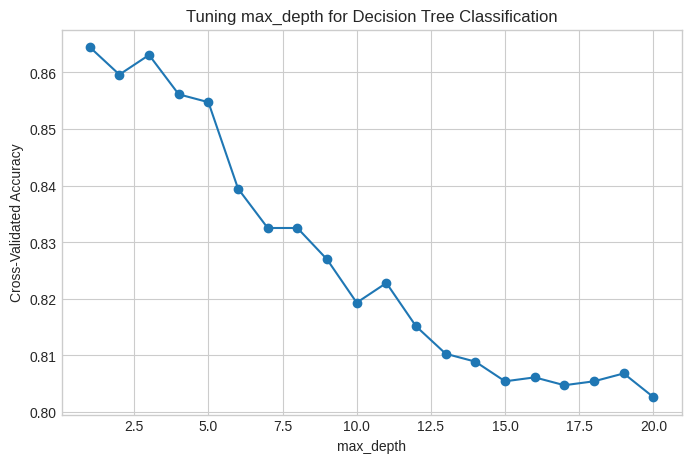

Best max_depth: 1
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       251
           1       0.00      0.00      0.00        37

    accuracy                           0.87       288
   macro avg       0.44      0.50      0.47       288
weighted avg       0.76      0.87      0.81       288



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
"""Decision Tree"""

# Used the code from week 9 recitation

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt



depths = list(range(1, 21))
cv_scores = []



for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=1)
    scores = cross_val_score(tree, X_clf, y_clf, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(depths, cv_scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Tuning max_depth for Decision Tree Classification")
plt.grid(True)
plt.show()

best_depth = depths[np.argmax(cv_scores)]
print(f"Best max_depth: {best_depth}")




#Used code from Claude with the prompt "integrate a classification report"

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
final_tree.fit(X_train, y_train)
y_pred = final_tree.predict(X_test)

print(classification_report(y_test, y_pred))

Note: The decision tree scored even worse than KNN because of the imbalance in the dataset.

In [73]:
"""Random Forest"""
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.datasets import make_classification



depths = [3, 5, 10, 15]
estimators = [10, 50, 100]
results = {}

for d in depths:
    for n in estimators:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, class_weight='balanced', random_state=42)
        score = cross_val_score(rf, X_clf, y_clf, cv=5, scoring='f1').mean()
        results[(d, n)] = score

best_params = max(results, key=results.get)
print(f"Best max_depth: {best_params[0]}, Best n_estimators: {best_params[1]}")
print(f"Best CV F1: {results[best_params]:.2f}")



#Used code from Claude with the prompt "integrate a classification report"
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
final_rf = RandomForestClassifier(n_estimators=best_params[1], max_depth=best_params[0], random_state=42)
final_rf.fit(X_train, y_train)
y_pred = final_rf.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))


Best max_depth: 5, Best n_estimators: 10
Best CV F1: 0.47
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.33      0.05      0.09        37

    accuracy                           0.86       288
   macro avg       0.60      0.52      0.51       288
weighted avg       0.81      0.86      0.82       288



In [64]:
"""Logistic Regression"""
#Used code from recitation 8

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


clf = LogisticRegression()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # Probability of class 1



print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       251
           1       0.00      0.00      0.00        37

    accuracy                           0.87       288
   macro avg       0.44      0.50      0.47       288
weighted avg       0.76      0.87      0.81       288

Confusion Matrix:
[[251   0]
 [ 37   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


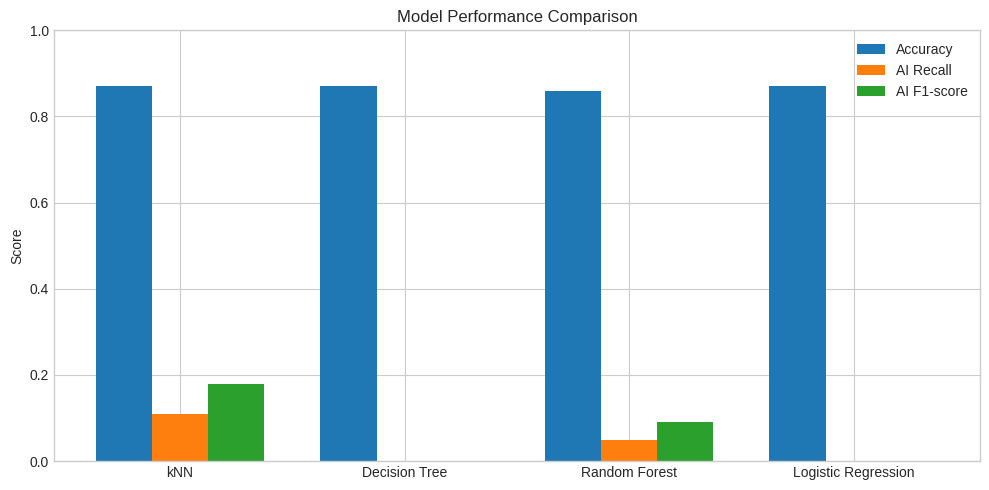

In [76]:
models = ['kNN', 'Decision Tree', 'Random Forest', 'Logistic Regression']
accuracy = [0.87, 0.87, 0.86, 0.87]
recall_ai = [0.11, 0.00, 0.05, 0.00]
f1_ai = [0.18, 0.00, 0.09, 0.00]

x = range(len(models))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar([i - width for i in x], accuracy, width=width, label='Accuracy')
plt.bar(x, recall_ai, width=width, label='AI Recall')
plt.bar([i + width for i in x], f1_ai, width=width, label='AI F1-score')

plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()

plt.tight_layout()
plt.show()